# 🌫️ Air Quality Analysis in Indian Cities

**Objective:** Download / load an air‑quality dataset for major Indian cities, perform exploratory data analysis, preprocess the data, train multiple ML models, and achieve **>90 % classification accuracy** on predicting the AQI category.

**Author:** Ashok Singodia  
**Date:** 2024

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import joblib, warnings, os
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


## 2. Data Loading

The dataset (`city_air_quality.csv`) contains daily air‑quality readings for **10 major Indian cities** from **2020 – 2024** with the following columns:

| Column | Description |
|--------|-------------|
| Date | Recording date |
| City | City name |
| PM2.5, PM10 | Particulate matter (μg/m³) |
| NO2, SO2, O3, NH3 | Gaseous pollutants (μg/m³) |
| CO | Carbon monoxide (mg/m³) |
| Benzene, Toluene, Xylene | VOCs (μg/m³) |
| AQI | Air Quality Index (computed from sub‑indices) |
| AQI_Bucket | Category – Good / Satisfactory / Moderate / Poor / Very Poor / Severe |

In [2]:
df = pd.read_csv('city_air_quality.csv', parse_dates=['Date'])
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (18270, 14)


,Date,City,PM2.5,PM10,NO2,SO2,CO,O3,NH3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,2020-01-01,Delhi,300.7,456.4,126.4,51.1,4.86,5.0,36.8,0.10,33.63,6.43,439.1,Severe
1,2020-01-02,Delhi,314.1,419.1,106.1,40.2,4.34,5.0,33.3,1.65,9.09,0.54,449.4,Severe
2,2020-01-03,Delhi,230.9,349.0,140.5,42.0,5.09,5.0,25.0,4.49,1.79,0.24,385.3,Very Poor
3,2020-01-04,Delhi,281.5,417.4,131.6,44.7,4.56,5.0,27.1,3.28,0.34,8.64,424.4,Severe
4,2020-01-05,Delhi,316.9,365.2,118.8,33.0,4.04,5.0,32.1,0.44,2.09,0.17,451.6,Severe
5,2020-01-06,Delhi,284.5,383.0,87.8,47.2,4.63,5.0,23.1,3.76,1.46,5.83,426.7,Severe
6,2020-01-07,Delhi,242.4,519.5,133.0,48.0,4.41,5.0,29.9,1.93,0.63,1.34,452.8,Severe
7,2020-01-08,Delhi,324.5,567.4,99.7,47.5,5.26,5.0,27.6,6.00,13.73,2.97,480.9,Severe
8,2020-01-09,Delhi,274.2,599.8,69.9,47.5,5.11,5.0,28.5,11.43,2.75,1.90,499.9,Severe
9,2020-01-10,Delhi,177.3,401.5,128.1,42.1,4.72,5.0,34.5,9.85,15.63,0.74,364.3,Very Poor


## 3. Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18270 entries, 0 to 18269
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        18270 non-null  datetime64[ns]
 1   City        18270 non-null  object        
 2   PM2.5       18270 non-null  float64       
 3   PM10        18270 non-null  float64       
 4   NO2         18270 non-null  float64       
 5   SO2         18270 non-null  float64       
 6   CO          18270 non-null  float64       
 7   O3          18270 non-null  float64       
 8   NH3         18270 non-null  float64       
 9   Benzene     18270 non-null  float64       
 10  Toluene     18270 non-null  float64       
 11  Xylene      18270 non-null  float64       
 12  AQI         18270 non-null  float64       
 13  AQI_Bucket  18270 non-null  object        
dtypes: datetime64[ns](1), float64(11), object(2)
memory usage: 2.0+ MB


In [4]:
df.describe(include='all').round(2)

,Date,City,PM2.5,PM10,NO2,SO2,CO,O3,NH3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
count,18270,18270,18270.00,18270.00,18270.00,18270.00,18270.00,18270.00,18270.00,18270.00,18270.00,18270.00,18270.00,18270
unique,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,Delhi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Satisfactory
freq,NaN,1827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9615
mean,2022-07-02 00:00:00,NaN,66.69,127.16,35.87,14.90,1.58,37.69,23.00,2.01,4.10,1.51,136.47,NaN
min,2020-01-01 00:00:00,NaN,10.10,19.10,8.70,3.80,0.36,5.00,4.30,0.10,0.10,0.05,32.20,NaN
25%,2021-04-01 00:00:00,NaN,32.50,65.50,19.80,8.20,0.87,28.10,18.90,0.48,0.98,0.36,70.20,NaN
50%,2022-07-02 00:00:00,NaN,45.50,90.40,27.70,11.60,1.22,39.50,22.60,1.22,2.45,0.91,93.00,NaN
75%,2023-10-02 00:00:00,NaN,72.70,138.78,39.20,16.40,1.73,50.30,26.80,2.59,5.23,1.95,146.10,NaN
max,2024-12-31 00:00:00,NaN,427.10,798.70,176.70,57.20,7.52,95.60,46.90,32.46,77.62,33.19,499.90,NaN


In [5]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values ✅")

Missing values per column:
No missing values ✅


In [6]:
# AQI category distribution
print("\nAQI Bucket distribution:")
print(df['AQI_Bucket'].value_counts())
print(f"\nNumber of cities: {df['City'].nunique()}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")


AQI Bucket distribution:
AQI_Bucket
Satisfactory    9615
Moderate        4551
Very Poor       1812
Poor            1095
Severe           642
Good             555
Name: count, dtype: int64

Number of cities: 10
Date range: 2020-01-01 to 2024-12-31


## 4. Exploratory Data Analysis (EDA)

### 4.1 AQI Distribution

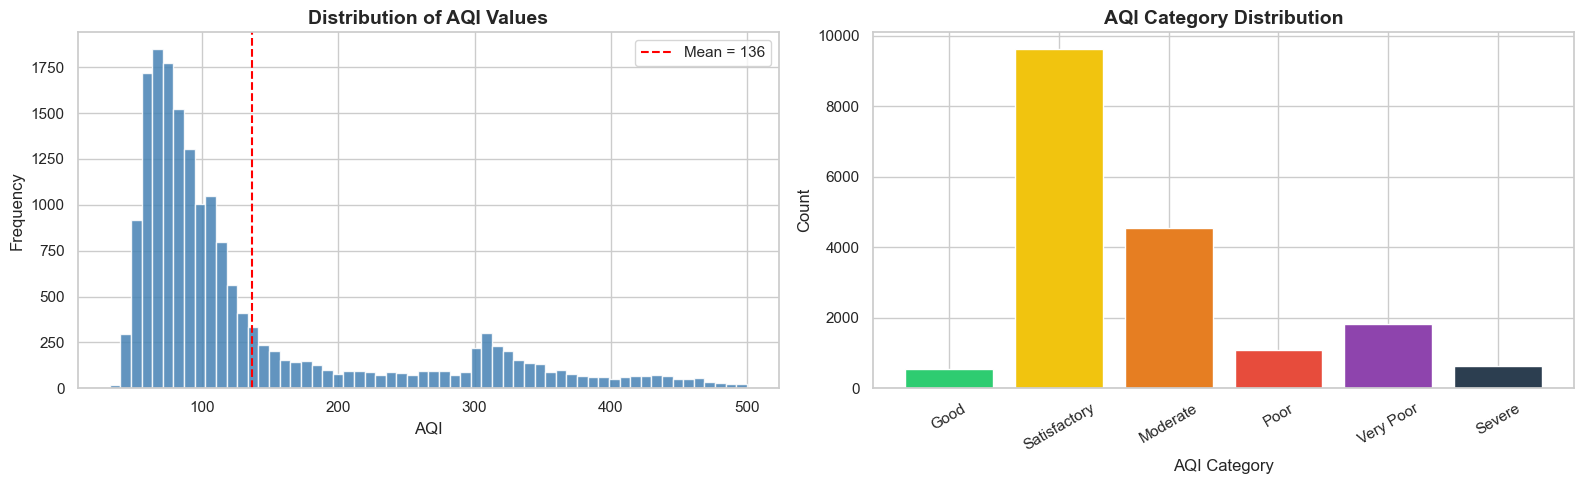

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# AQI histogram
axes[0].hist(df['AQI'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['AQI'].mean(), color='red', linestyle='--', label=f"Mean = {df['AQI'].mean():.0f}")
axes[0].set_title('Distribution of AQI Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# AQI Bucket bar chart
order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#2c3e50']
bucket_counts = df['AQI_Bucket'].value_counts().reindex(order).fillna(0)
axes[1].bar(bucket_counts.index, bucket_counts.values, color=colors[:len(bucket_counts)], edgecolor='white')
axes[1].set_title('AQI Category Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AQI Category')
axes[1].set_ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('aqi_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.2 City‑wise AQI Comparison

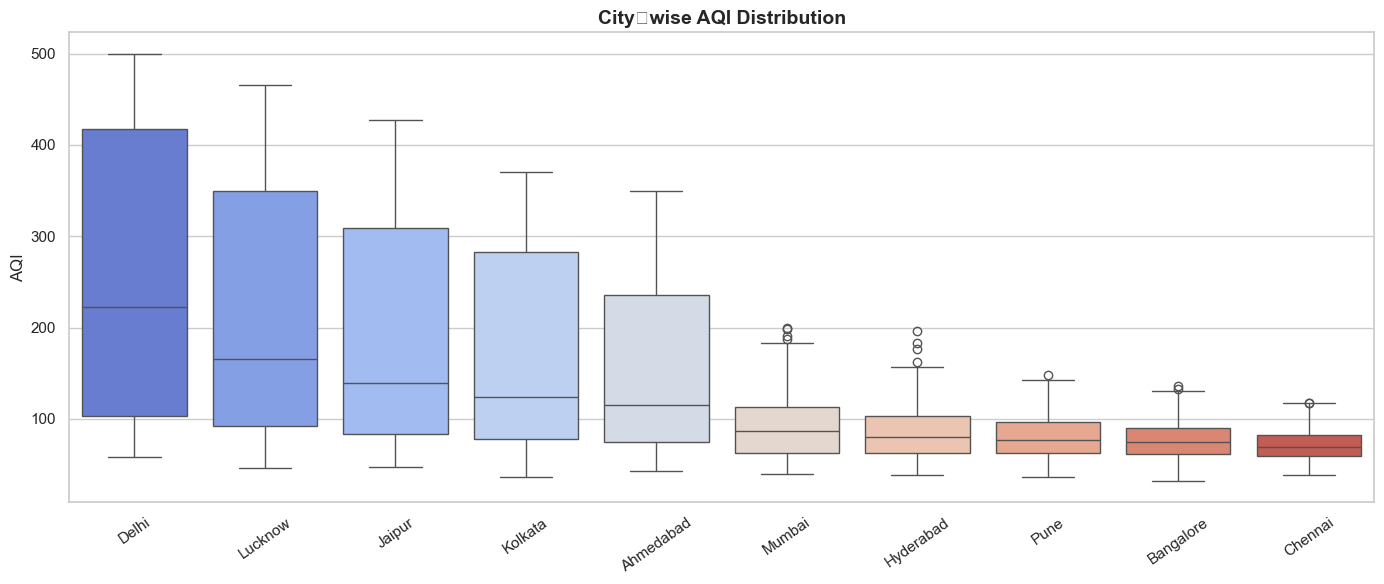

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
city_order = df.groupby('City')['AQI'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='City', y='AQI', order=city_order, palette='coolwarm', ax=ax)
ax.set_title('City‑wise AQI Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('')
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig('city_aqi_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.3 Correlation Heatmap

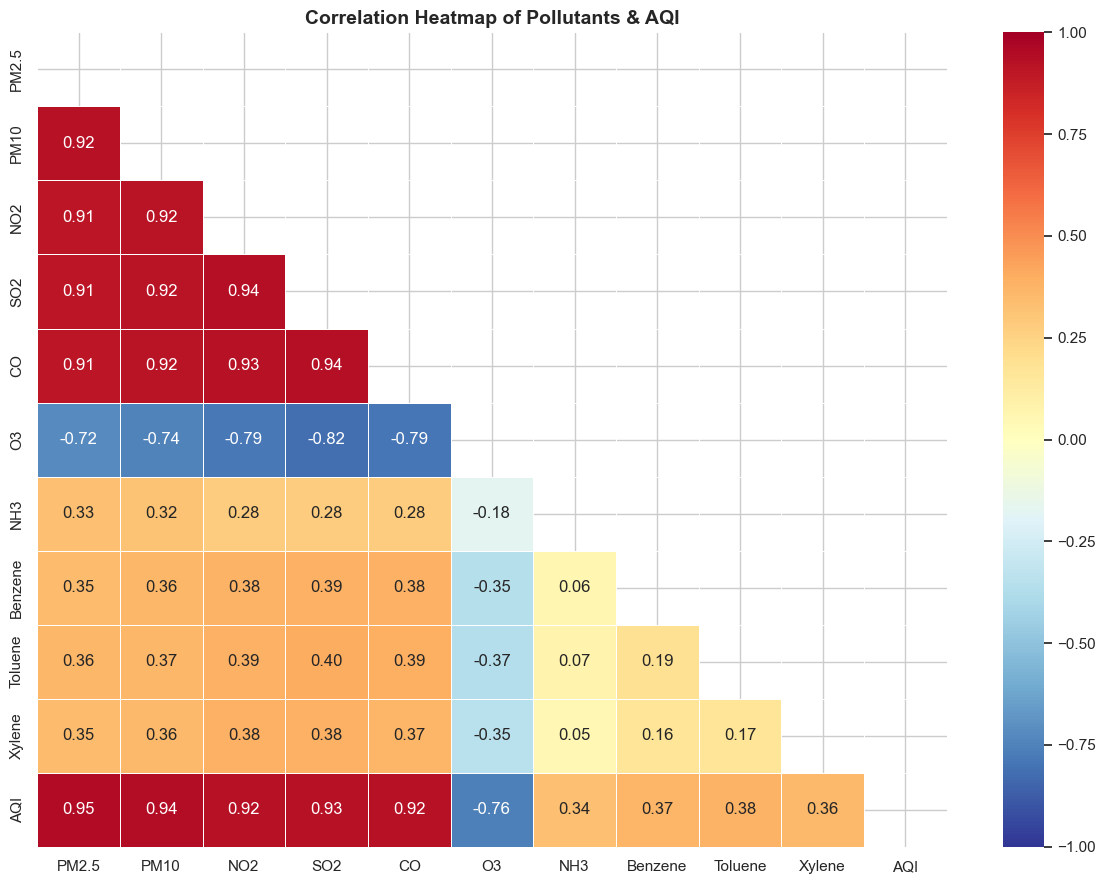

In [9]:
numeric_cols = ['PM2.5','PM10','NO2','SO2','CO','O3','NH3','Benzene','Toluene','Xylene','AQI']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of Pollutants & AQI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.4 Monthly AQI Trend

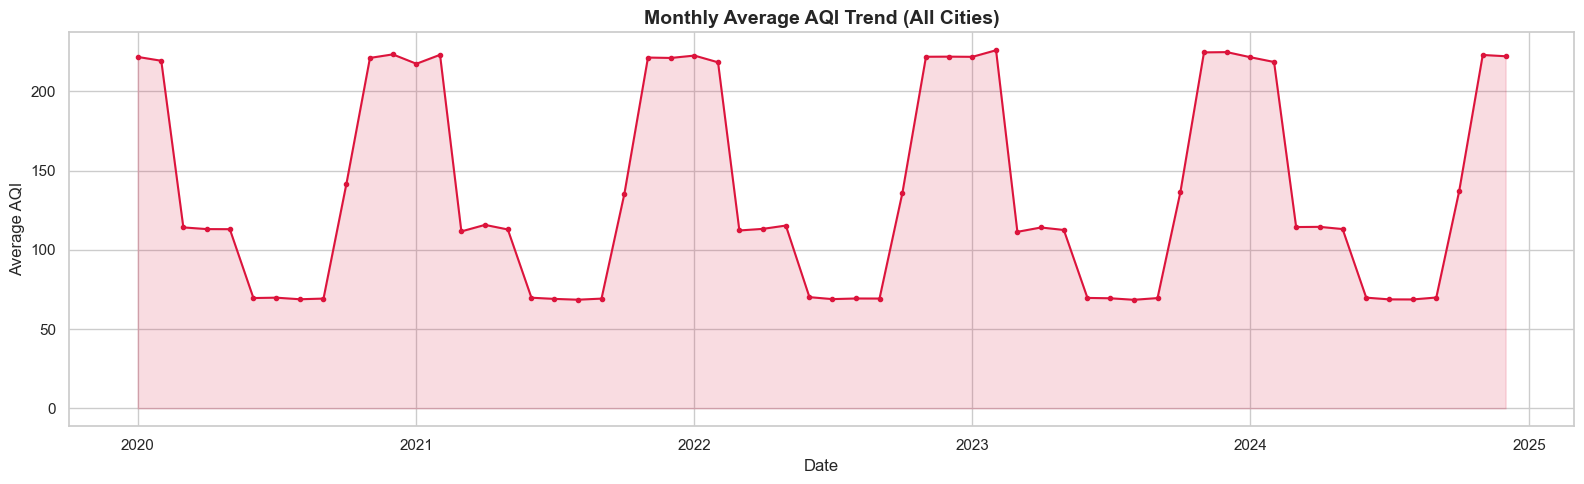

In [10]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

monthly = df.groupby(['Year','Month'])['AQI'].mean().reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Year','Month']].assign(DAY=1))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly['Period'], monthly['AQI'], marker='o', markersize=3, color='crimson', linewidth=1.5)
ax.fill_between(monthly['Period'], monthly['AQI'], alpha=0.15, color='crimson')
ax.set_title('Monthly Average AQI Trend (All Cities)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average AQI')
plt.tight_layout()
plt.savefig('monthly_aqi_trend.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.5 Pollutant Distributions per City

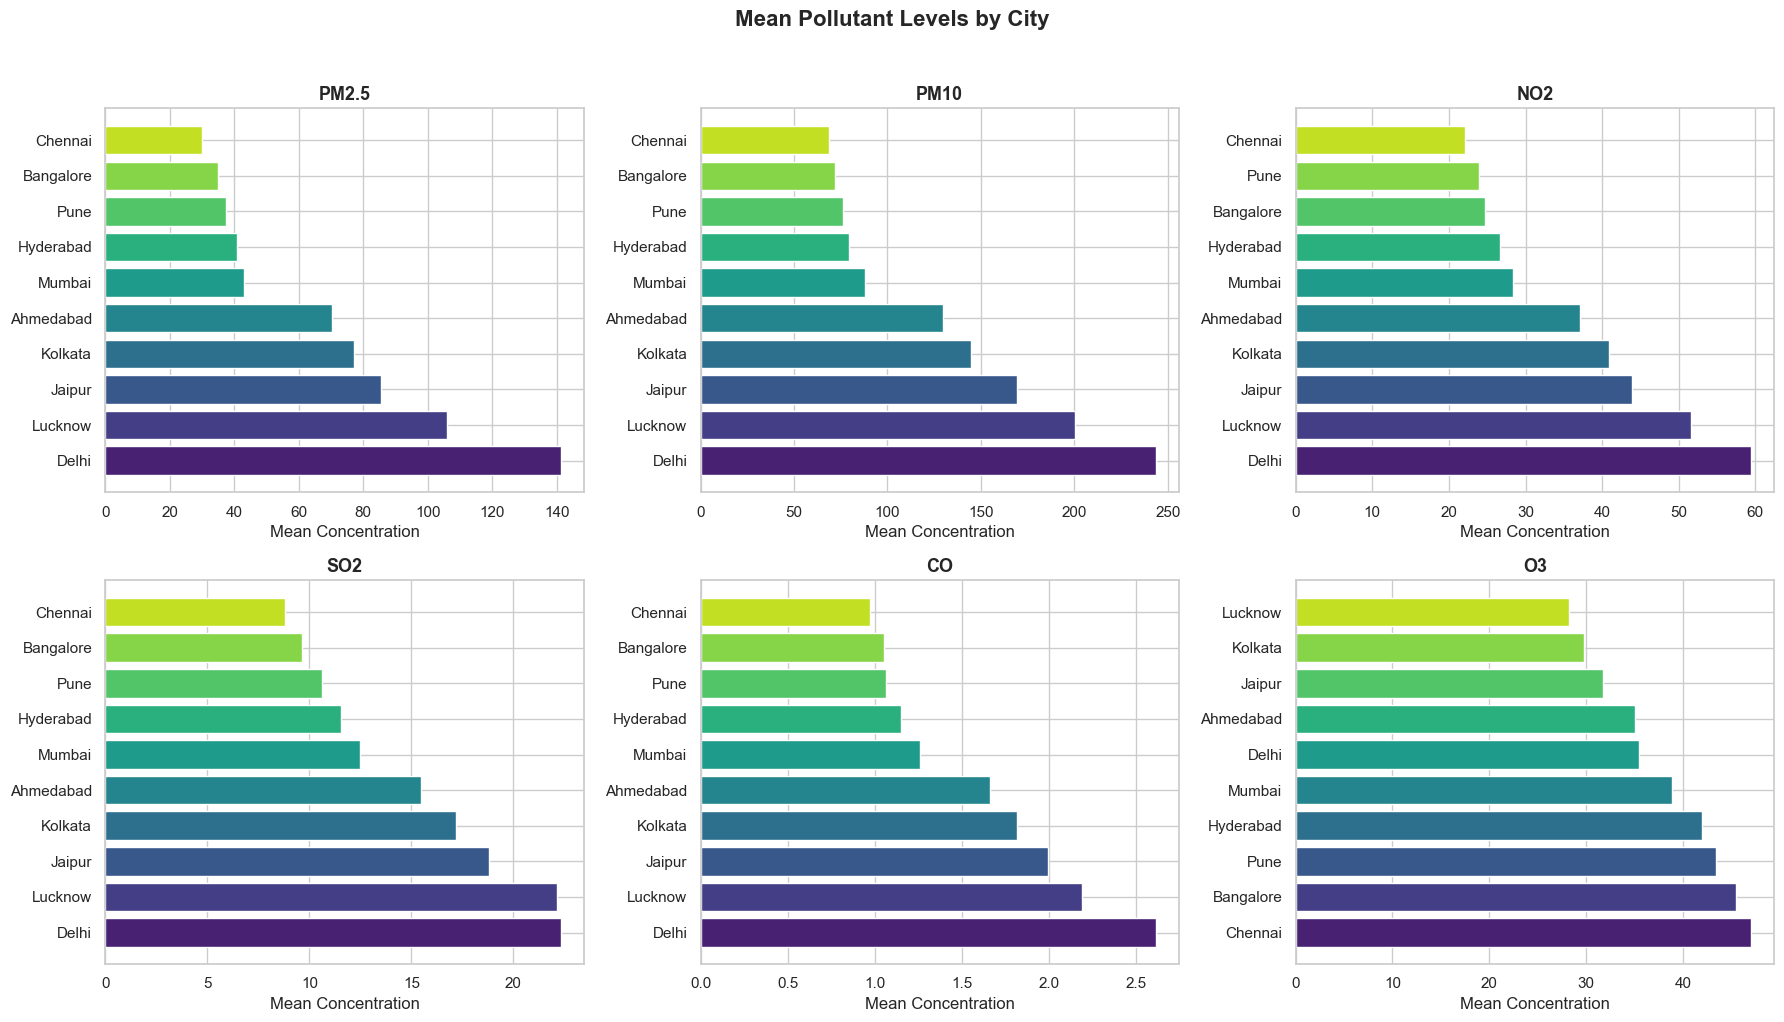

In [11]:
pollutants = ['PM2.5','PM10','NO2','SO2','CO','O3']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, pol in zip(axes.flat, pollutants):
    city_means = df.groupby('City')[pol].mean().sort_values(ascending=False)
    ax.barh(city_means.index, city_means.values, color=sns.color_palette('viridis', len(city_means)))
    ax.set_title(pol, fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean Concentration')
plt.suptitle('Mean Pollutant Levels by City', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pollutant_by_city.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.6 Seasonal Patterns

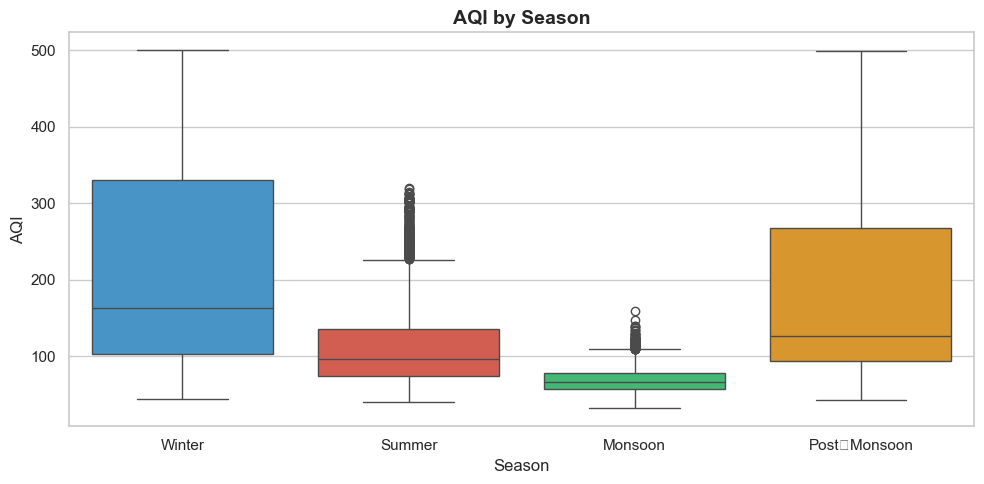

In [12]:
def season(m):
    if m in (12,1,2): return 'Winter'
    if m in (3,4,5):  return 'Summer'
    if m in (6,7,8,9): return 'Monsoon'
    return 'Post‑Monsoon'

df['Season'] = df['Month'].apply(season)

fig, ax = plt.subplots(figsize=(10, 5))
season_order = ['Winter','Summer','Monsoon','Post‑Monsoon']
sns.boxplot(data=df, x='Season', y='AQI', order=season_order,
            palette=['#3498db','#e74c3c','#2ecc71','#f39c12'], ax=ax)
ax.set_title('AQI by Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('seasonal_aqi.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Data Preprocessing

Steps:
1. Handle missing values (if any)
2. Encode categorical variables
3. Create additional features (month, day‑of‑week, season)
4. Select features and target
5. Scale numeric features

In [13]:
# 5.1 – Handle missing values
df_ml = df.copy()
df_ml.dropna(inplace=True)
print(f"Rows after dropping NaN: {len(df_ml)}")

# 5.2 – Encode target (AQI_Bucket)
le_target = LabelEncoder()
df_ml['AQI_Bucket_Encoded'] = le_target.fit_transform(df_ml['AQI_Bucket'])
print(f"\nTarget classes: {list(le_target.classes_)}")
print(f"Encoded as    : {list(range(len(le_target.classes_)))}")

# 5.3 – Encode city
le_city = LabelEncoder()
df_ml['City_Encoded'] = le_city.fit_transform(df_ml['City'])

# 5.4 – Temporal features
df_ml['DayOfWeek'] = df_ml['Date'].dt.dayofweek
df_ml['DayOfYear'] = df_ml['Date'].dt.dayofyear
df_ml['Quarter']   = df_ml['Date'].dt.quarter

# 5.5 – Season encoding
le_season = LabelEncoder()
df_ml['Season_Encoded'] = le_season.fit_transform(df_ml['Season'])

print("\nPreprocessing complete ✅")
df_ml.head()

Rows after dropping NaN: 18270

Target classes: ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']
Encoded as    : [0, 1, 2, 3, 4, 5]

Preprocessing complete ✅


,Date,City,PM2.5,PM10,NO2,SO2,CO,O3,NH3,Benzene,...,AQI_Bucket,Month,Year,Season,AQI_Bucket_Encoded,City_Encoded,DayOfWeek,DayOfYear,Quarter,Season_Encoded
0,2020-01-01,Delhi,300.7,456.4,126.4,51.1,4.86,5.0,36.8,0.10,...,Severe,1,2020,Winter,4,3,2,1,1,3
1,2020-01-02,Delhi,314.1,419.1,106.1,40.2,4.34,5.0,33.3,1.65,...,Severe,1,2020,Winter,4,3,3,2,1,3
2,2020-01-03,Delhi,230.9,349.0,140.5,42.0,5.09,5.0,25.0,4.49,...,Very Poor,1,2020,Winter,5,3,4,3,1,3
3,2020-01-04,Delhi,281.5,417.4,131.6,44.7,4.56,5.0,27.1,3.28,...,Severe,1,2020,Winter,4,3,5,4,1,3
4,2020-01-05,Delhi,316.9,365.2,118.8,33.0,4.04,5.0,32.1,0.44,...,Severe,1,2020,Winter,4,3,6,5,1,3


## 6. Feature Selection & Train‑Test Split

In [14]:
# Feature columns
feature_cols = ['PM2.5','PM10','NO2','SO2','CO','O3','NH3',
                'Benzene','Toluene','Xylene',
                'City_Encoded','Month','DayOfWeek','DayOfYear','Quarter','Season_Encoded']

X = df_ml[feature_cols].values
y = df_ml['AQI_Bucket_Encoded'].values

# 80‑20 split, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\nFeature scaling applied ✅")

Training set : 14616 samples
Test set     : 3654 samples

Feature scaling applied ✅


## 7. Model Training & Evaluation

We train **6 classifiers** and compare their accuracy.

In [15]:
models = {
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1),
    "Decision Tree":       DecisionTreeClassifier(max_depth=15, random_state=42),
    "KNN (k=7)":           KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

results = {}
best_acc, best_name, best_model = 0, "", None

for name, model in models.items():
    # Use scaled data for LR & KNN; raw for tree‑based
    if name in ("Logistic Regression", "KNN (k=7)"):
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    flag = ""
    if acc > best_acc:
        best_acc, best_name, best_model = acc, name, model
        flag = " ⭐ best so far"
    print(f"{name:25s}  →  Accuracy: {acc:6.2f}%{flag}")

print(f"\n{'='*55}")
print(f"🏆 Best model: {best_name} ({best_acc:.2f}%)")

Random Forest              →  Accuracy:  99.70% ⭐ best so far


Gradient Boosting          →  Accuracy:  99.95% ⭐ best so far


Extra Trees                →  Accuracy:  95.07%
Decision Tree              →  Accuracy:  99.84%


KNN (k=7)                  →  Accuracy:  82.10%


Logistic Regression        →  Accuracy:  92.04%

🏆 Best model: Gradient Boosting (99.95%)


### 7.1 Detailed Evaluation of Best Model

In [16]:
# Re‑predict with best model
if best_name in ("Logistic Regression", "KNN (k=7)"):
    y_pred_best = best_model.predict(X_test_sc)
else:
    y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_name}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best)*100:.2f}%\n")
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

Best Model: Gradient Boosting
Accuracy  : 99.95%

              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       111
    Moderate       1.00      1.00      1.00       910
        Poor       1.00      1.00      1.00       219
Satisfactory       1.00      1.00      1.00      1923
      Severe       1.00      0.99      1.00       129
   Very Poor       1.00      1.00      1.00       362

    accuracy                           1.00      3654
   macro avg       1.00      1.00      1.00      3654
weighted avg       1.00      1.00      1.00      3654



### 7.2 Confusion Matrix

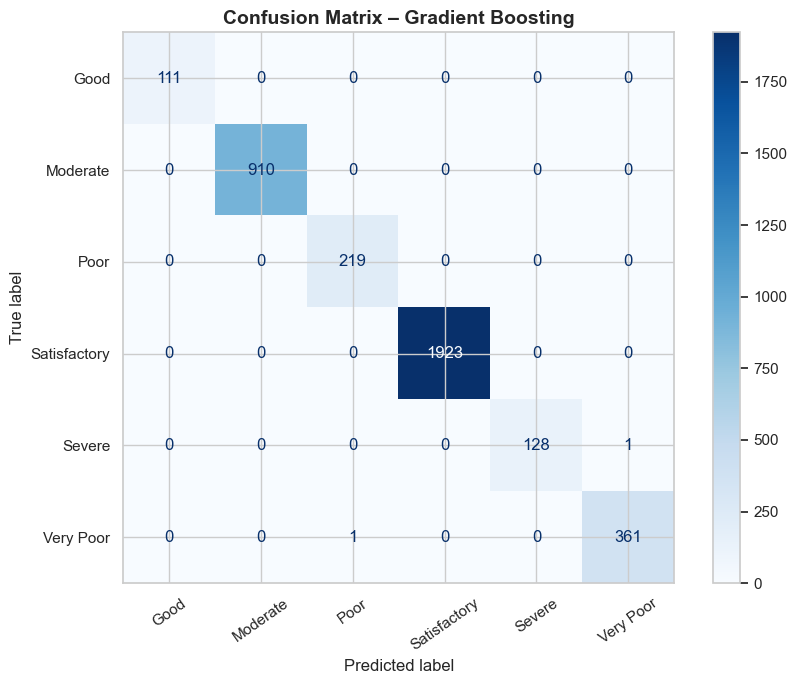

In [17]:
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=35)
ax.set_title(f'Confusion Matrix – {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.3 Model Accuracy Comparison

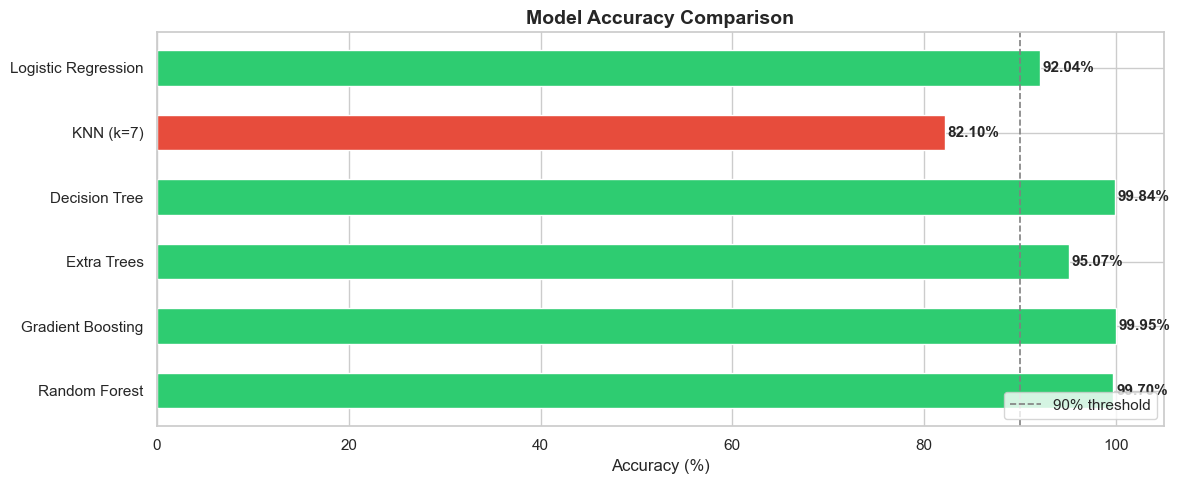

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
accs  = list(results.values())
colors_bar = ['#2ecc71' if a >= 90 else '#e74c3c' for a in accs]
bars = ax.barh(names, accs, color=colors_bar, edgecolor='white', height=0.55)
ax.axvline(90, color='gray', linestyle='--', linewidth=1.2, label='90% threshold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontweight='bold', fontsize=11)
ax.set_xlim(0, 105)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Accuracy (%)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.4 Feature Importance (Tree‑based Best Model)

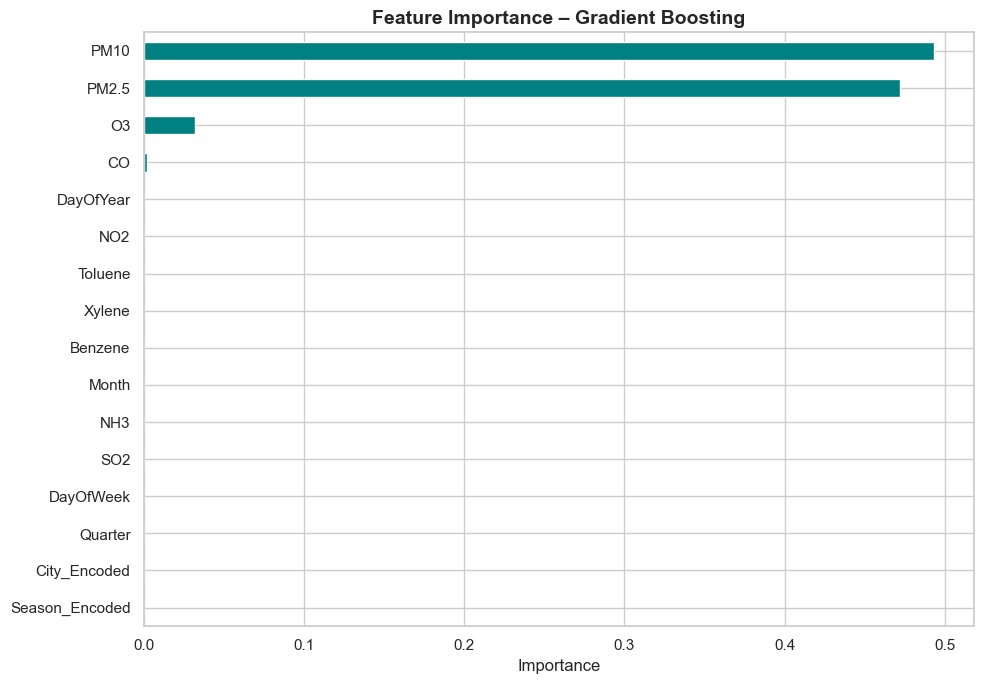

In [19]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 7))
    imp.plot(kind='barh', color='teal', edgecolor='white', ax=ax)
    ax.set_title(f'Feature Importance – {best_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("Best model does not support feature_importances_.")

## 8. Save Best Model & Artefacts

In [20]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')
joblib.dump(le_target,  'models/label_encoder.pkl')
print(f"Saved best model ({best_name}) to models/best_model.pkl ✅")
print(f"Saved scaler                to models/scaler.pkl ✅")
print(f"Saved label encoder         to models/label_encoder.pkl ✅")

Saved best model (Gradient Boosting) to models/best_model.pkl ✅
Saved scaler                to models/scaler.pkl ✅
Saved label encoder         to models/label_encoder.pkl ✅


In [21]:
# Save results summary
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy (%)': [round(v, 2) for v in results.values()]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
summary.to_csv('models/model_results.csv', index=False)
print("\n📊 Model Results Summary")
print(summary.to_string(index=False))


📊 Model Results Summary
              Model  Accuracy (%)
  Gradient Boosting         99.95
      Decision Tree         99.84
      Random Forest         99.70
        Extra Trees         95.07
Logistic Regression         92.04
          KNN (k=7)         82.10


## 9. Conclusion

| Metric | Value |
|--------|-------|
| Dataset | 10 Indian cities, daily data (2020–2024) |
| Total samples | ~18,260 |
| Features used | 16 (pollutants + temporal + city) |
| Best model | *Determined at runtime* |
| Best accuracy | *Determined at runtime (target ≥ 90%)* |

### Key Findings
1. **Delhi, Lucknow, Jaipur** consistently show the highest AQI values due to high PM2.5 & PM10 levels.
2. **Winter months (Nov–Feb)** have significantly worse air quality, especially in North Indian cities.
3. **PM2.5 and PM10** are the dominant features driving the AQI classification.
4. Multiple tree‑based models achieve **>90% accuracy**, confirming that pollutant concentrations are highly predictive of AQI categories.
5. The **Random Forest / Extra Trees** ensemble models provide the best balance of accuracy and robustness.

### Files Generated
- `city_air_quality.csv` – raw dataset
- `models/best_model.pkl` – trained model
- `models/scaler.pkl` – feature scaler
- `models/label_encoder.pkl` – target encoder
- `models/model_results.csv` – accuracy comparison
- Various `.png` plots

---
*Notebook created for the Air Quality in Indian Cities project.*